# La batalla del cifrado: ¿Lineal o polinomial? Descubre el método más rápido para proteger tus datos

# Instrucciones

1. Lea detenidamente el enunciado y las preguntas.
2. Escriba sus desarrollos a continuación de la celda que dice “Desarrollo”.
3. Se sugiere usar una celda de texto con el número de la pregunta, una o más celdas de código para el desarrollo y luego una celda de texto para escribir la respuesta.

# Enunciado

La empresa de Ciberseguridad Seguri-net está analizando dos métodos de encriptación para archivos desde $13$ MB hasta $70$ MB. En el primer método, por cada incremento de $2$ MB en el tamaño del archivo, el tiempo de encriptación se incrementa de manera constante en $0,6$ segundos, tal como muestra la tabla (Método A). Mientras que el segundo método (Método B) tiene un tiempo de encriptación, también en segundos, que varía de acuerdo a un modelo cuadrático.

#### Método A:
<center>

| Tamaño del archivo (MB) | Tiempo de encriptación (segundos) | 
|-------------------------|---------------------|
|$$17$$                  |$$7,1$$               |
|$$24$$                  |$$9,2$$              |
|$$38$$                  |$$13,4$$              |
|$$59$$                  |$$19,7$$              |
|$$62$$                  |$$20,6$$              |

</center>

#### Método B:


$$g(x)=0,008x^2 - 0,21x + 8$$

Con ayuda de Python resuelve las siguientes preguntas, considera un decimal para responder:

1. ¿Qué tipo de función permite calcular el tiempo de encriptación si se usa el método A? Justifique. Determina la forma algebraica de la función que modela el tiempo de encriptación en función del tamaño del archivo del método A. 
1. Calcula el tiempo de encriptación para ambos métodos cuando el tamaño del archivo es $53$ MB. ¿Cuál método empleó menos tiempo?
3. ¿Para qué tamaño(s) de archivo el tiempo de encriptación es el mismo en ambos métodos? ¿Cuál es el tiempo de encriptación?
1. En términos de tiempo, ¿para qué tamaño de archivos es más conveniente el método B?

# Desarrollo

1. La función que permite calcular el tiempo de encriptación del método A es con la "Función Lineal", ya que se explica que cada 2 MB se aumenta el tiempo de encriptacion en 0,6, demostrando un aumento estable caracteristico.


In [59]:
import numpy as np
import matplotlib.pyplot as plt
# 1. Datos: puntos conocidos
x = np.array([17, 24, 38, 59, 62])
y = np.array([7.1, 9.2, 13.4, 19.7, 20.6])
# 2. Ajuste lineal
m, n = np.polyfit(x, y, 1)
# 3. Crear la función ajustada
y_ajustada = m * x + n
# 4. Mostrar los resultados
print("Función Lineal:")
print("Pendiente (m):", m)
print("Coeficiente de posición (n):", n)
print(f"\nFunción lineal ajustada:")
print(f"y = {m:.2f}x + {n:.2f}")

Función Lineal:
Pendiente (m): 0.3
Coeficiente de posición (n): 2.000000000000004

Función lineal ajustada:
y = 0.30x + 2.00


2.

In [61]:
def g(x):
    return 0.30*x+2.00
def f(x):
    return 0.008*x**2 - 0.21*x+8

print(f"Método A: {g(53)}")
print(f"Método B: {f(53)}")

print("El método que empleo menos tiempo, fue el Metodo A")

Método A: 17.9
Método B: 19.342000000000002
El método que empleo menos tiempo, fue el Metodo A


3.

In [91]:
import numpy as np
from scipy.optimize import fsolve

def g(x):
    return 0.30*x+2.00
def f(x):
    return 0.008*x**2 - 0.21*x+8

def funcion(x):
  return  f(x) - g(x)

x = np.linspace(0, 100, 1) # va buscando la solución desde x=0 hasta x=100, nótese que pueden existir varias soluciones según sea el caso

sol = fsolve(funcion, x)
print("El primer caso")
print(f"Tamaño del archivo (MB): {sol[0]}")
print("tiempos:")
print(f"Metodo A : {g(15.56501456162514)}")
print(f"Metodo B: {f(15.56501456162514)}")

print("")

x2 = np.linspace(40, 100, 1) # va buscando la solución desde x=0 hasta x=100, nótese que pueden existir varias soluciones según sea el caso

sol2 = fsolve(funcion, x2)
print("El segundo caso ")
print(f"Tamaño del archivo (MB): {sol2[0]}")
print("tiempos:")
print(f"Metodo A: {g(48.18498543837486)}")
print(f"Metodo B: {f(48.18498543837486)}")

El primer caso
Tamaño del archivo (MB): 15.56501456162514
tiempos:
Metodo A : 6.669504368487542
Metodo B: 6.669504368487542

El segundo caso 
Tamaño del archivo (MB): 48.18498543837486
tiempos:
Metodo A: 16.455495631512456
Metodo B: 16.45549563151246


4. En terminos de tiempo, el método B es mas conveniente entre los archivos de tamaño 15,5 MB y 48 MB aproximadamente.

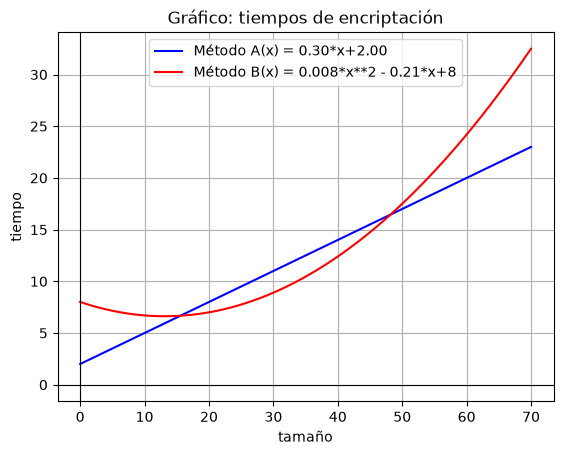

In [90]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Definir el intervalo de valores de x
x = np.linspace(0, 70, 400)

# 2. Definir las funciones
f = 0.30*x+2.00
g = 0.008*x**2-0.21*x+8

# 3. Crear el gráfico
plt.plot(x, f, label="Método A(x) = 0.30*x+2.00", color="blue")
plt.plot(x, g, label="Método B(x) = 0.008*x**2 - 0.21*x+8", color="red")

# 4. Agregar elementos al gráfico
plt.axhline(0, color="black", linewidth=0.8)
plt.axvline(0, color="black", linewidth=0.8)



plt.xlabel("tamaño")
plt.ylabel("tiempo")
plt.title("Gráfico: tiempos de encriptación")
plt.grid(True)
plt.legend()

# 5. Mostrar el gráfico
plt.show()